In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../datasets/Social_Network_Ads.csv")

In [15]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [16]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [17]:
df = df.iloc[:,2:]

In [18]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [19]:
df.sample(5)

,Age,EstimatedSalary,Purchased
261,36,144000,1
223,60,102000,1
59,32,117000,0
368,38,71000,0
202,39,134000,1


## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased", axis=1),
                                                   df["Purchased"],
                                                   test_size=0.3,
                                                    random_state=0)

In [22]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

## StandardScalar

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

3.786... its age mean, and 6.98...is salary mean. we learn on test data but transform both .

In [33]:
#X_train_scaled

In [36]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [37]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [38]:
np.round(X_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


## Effect of Scaling

Text(0.5, 1.0, 'After Scaling')

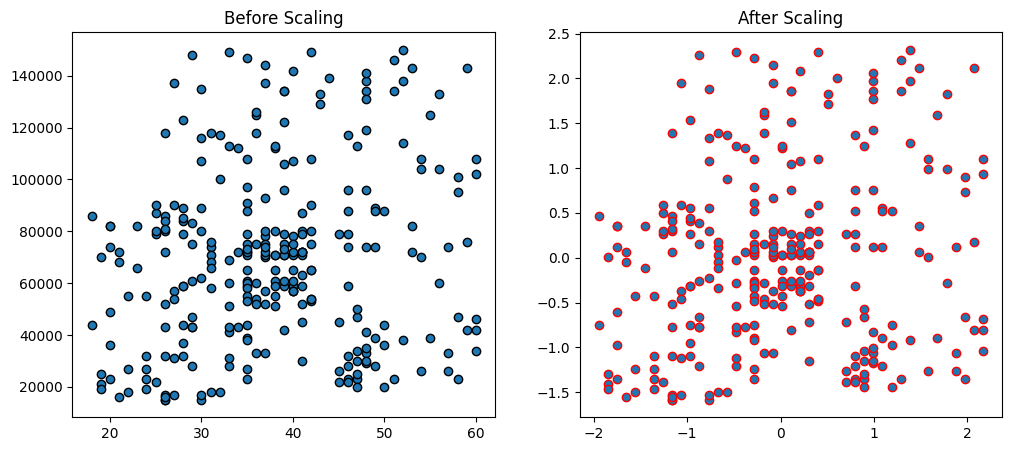

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Age"], X_train["EstimatedSalary"], edgecolor="k")
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"], edgecolor="red")
ax2.set_title("After Scaling")


These two graphs are similar but in first mean on 40 and after scaling its 0.

<Axes: title={'center': 'After Scaling'}, xlabel='Age', ylabel='Density'>

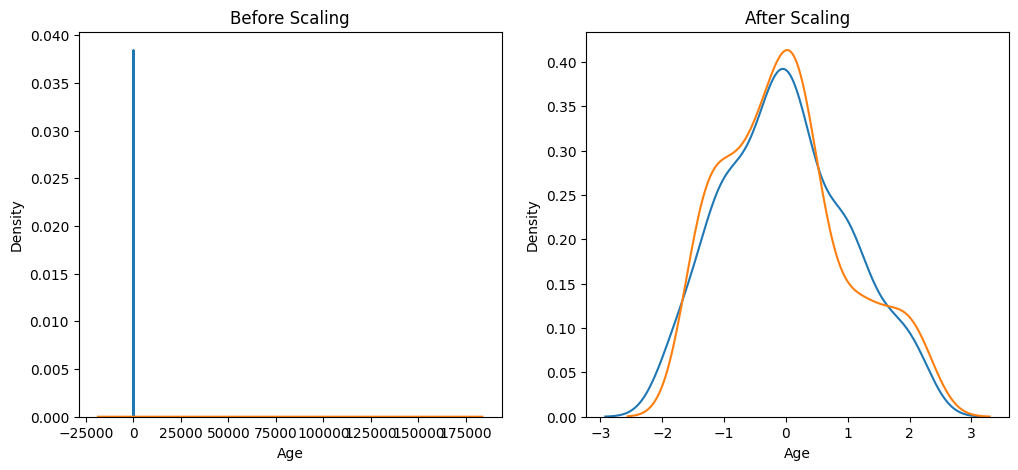

In [63]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"],ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"],ax=ax1)

# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"],ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"],ax=ax2)

Before scaling age was small and salary was high so we can't compare
But After, both are comparable, 

## Comparison of Distribution

<Axes: title={'center': 'Age Ditribution After Scaling'}, xlabel='Age', ylabel='Density'>

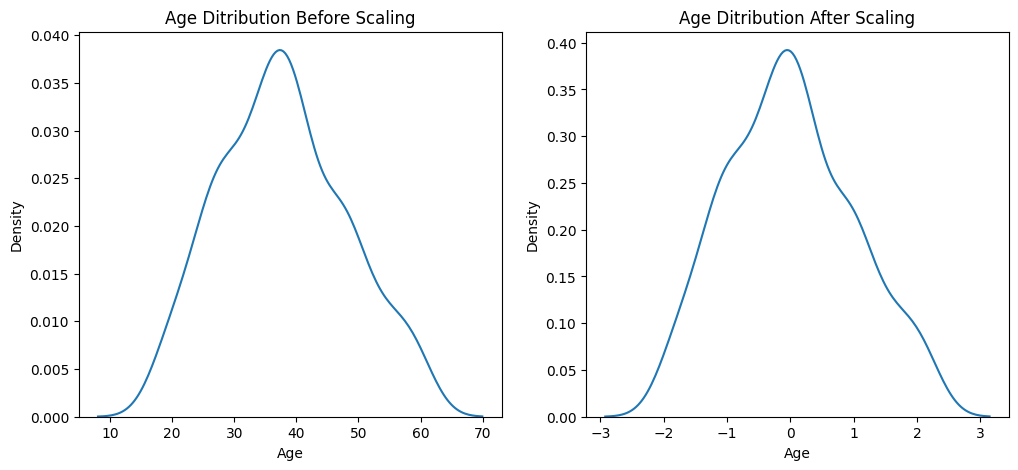

In [65]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))


# Before scaling
ax1.set_title("Age Ditribution Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)
# sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

# After scaling
ax2.set_title("Age Ditribution After Scaling")
sns.kdeplot(X_train_scaled_df["Age"], ax=ax2)
# sns.kdeplot(X_train_scaled_df["EstimatedSalary"], ax=ax2)



If you want to see what impact on separate columns then you will use them by this as below.. Distribution remains retained. When you apply standaridzation no specific effect happen at least in shape of the distribution no change. you just change scale and your mean is into 0 and std is into 1.

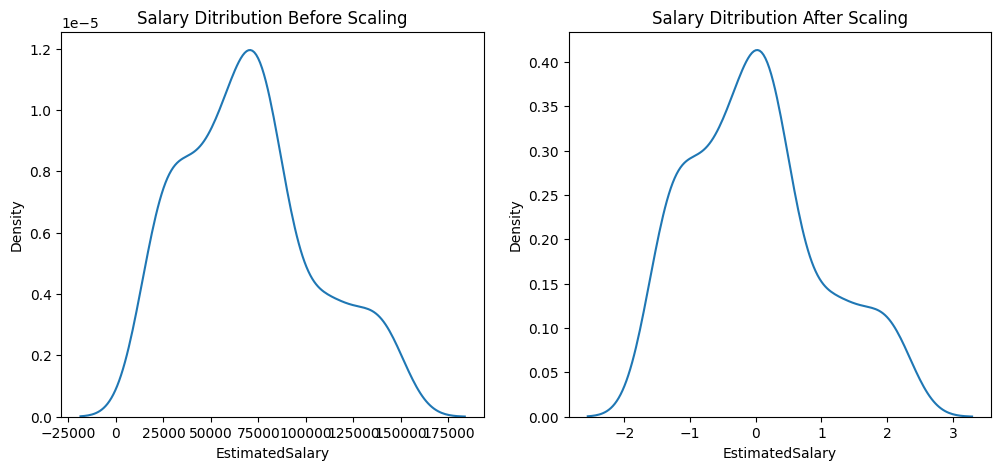

In [66]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before scaling
ax1.set_title("Salary Ditribution Before Scaling")
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)
# sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

# After scaling
ax2.set_title("Salary Ditribution After Scaling")
sns.kdeplot(X_train_scaled_df["EstimatedSalary"], ax=ax2)
# sns.kdeplot(X_train_scaled_df["EstimatedSalary"], ax=ax2)

plt.show()

## Why scaling is important

Logistic Regression is a machine-learning method used for YES / NO type decisions.
>
>
Logistic Regression is a classification algorithm that predicts probabilities using the sigmoid function

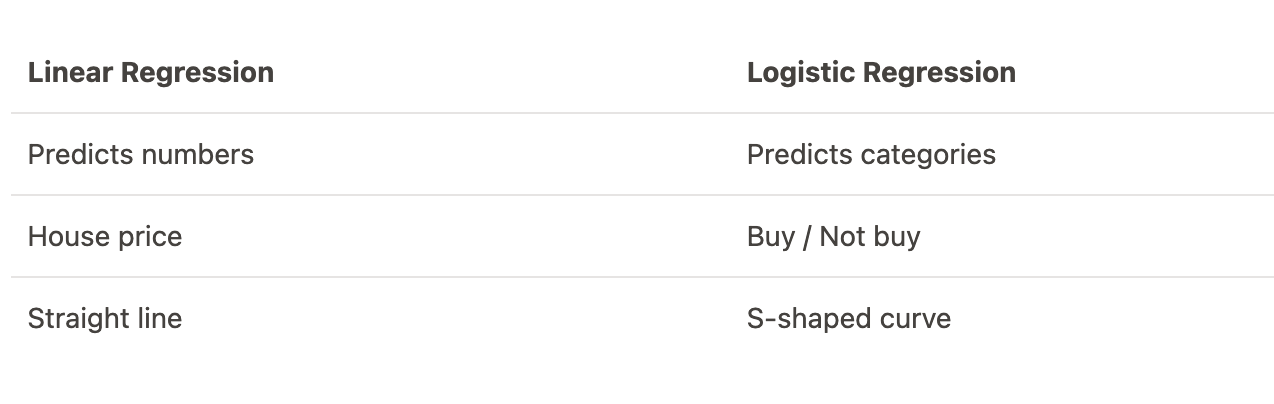

In [69]:
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [71]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)


y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

 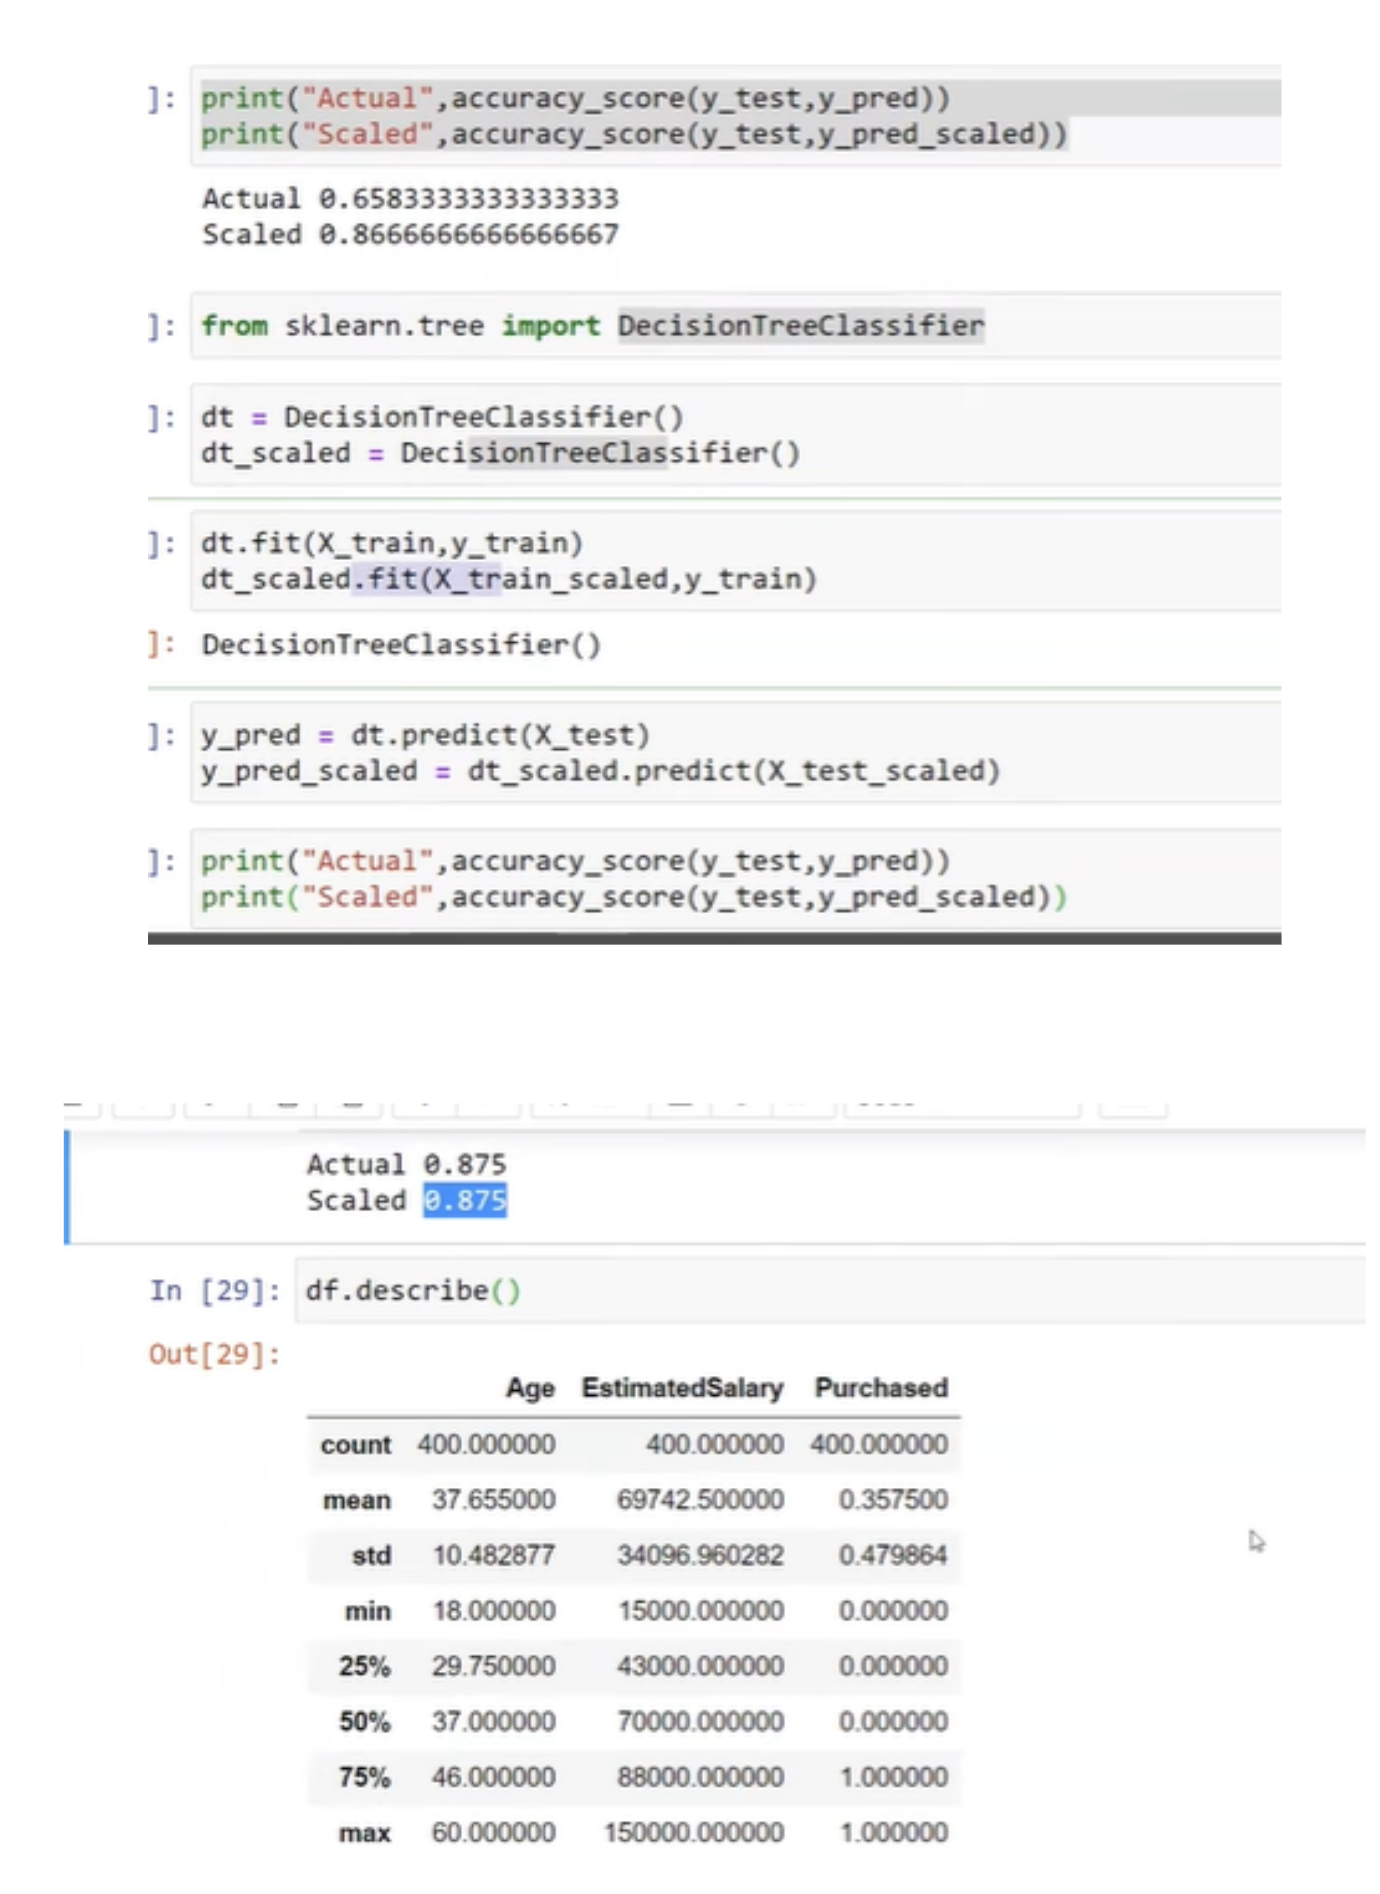

## Effect of Outlier

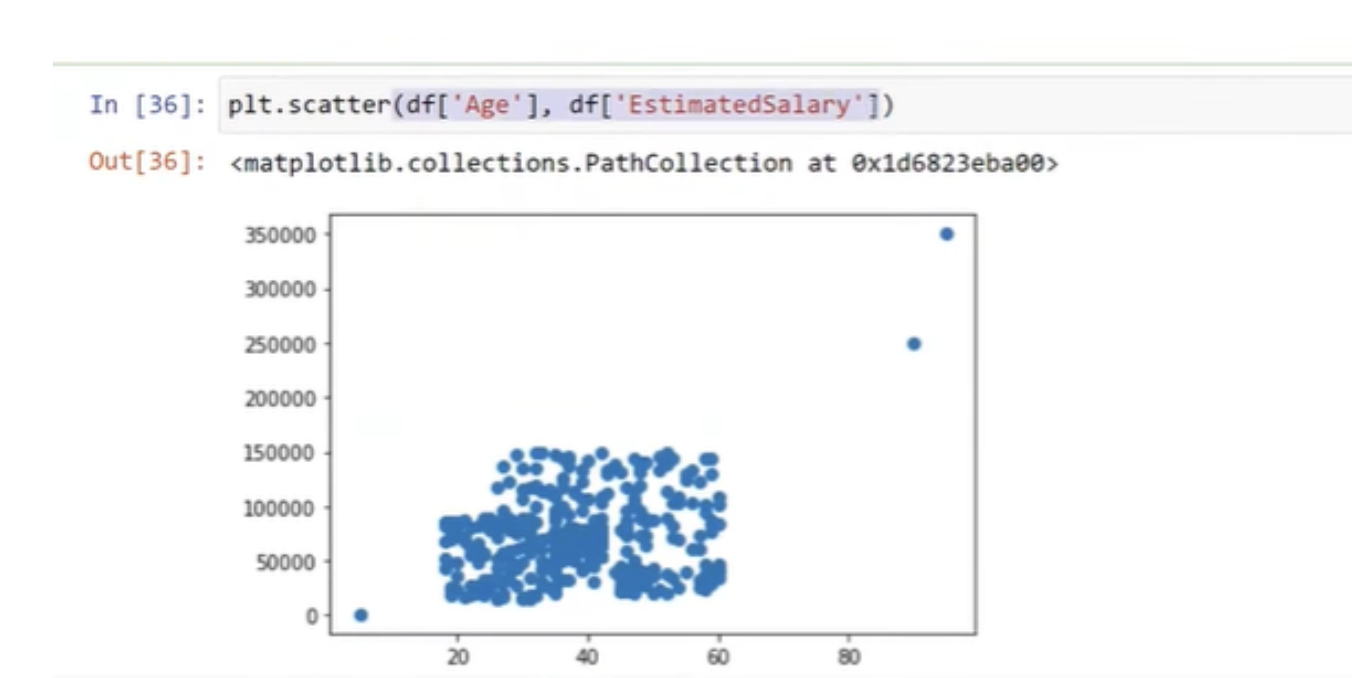

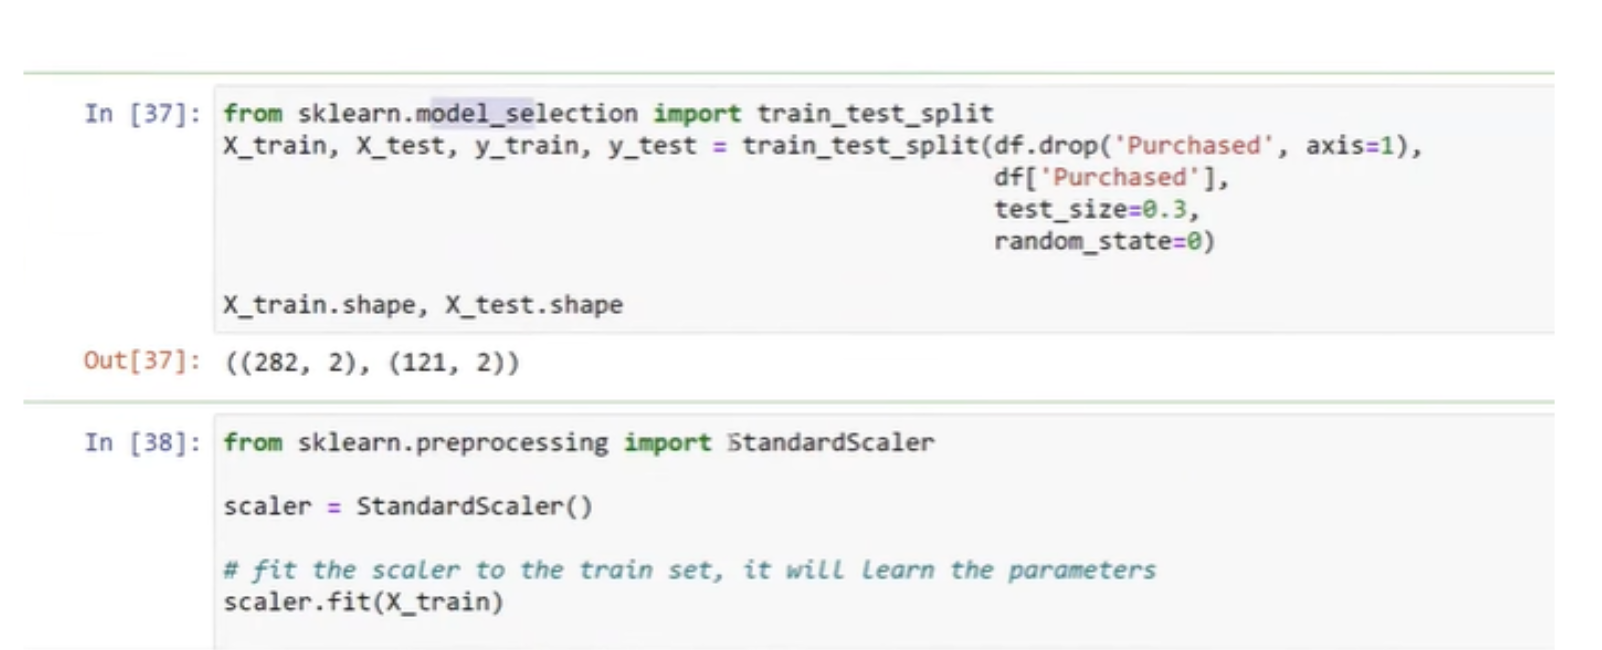

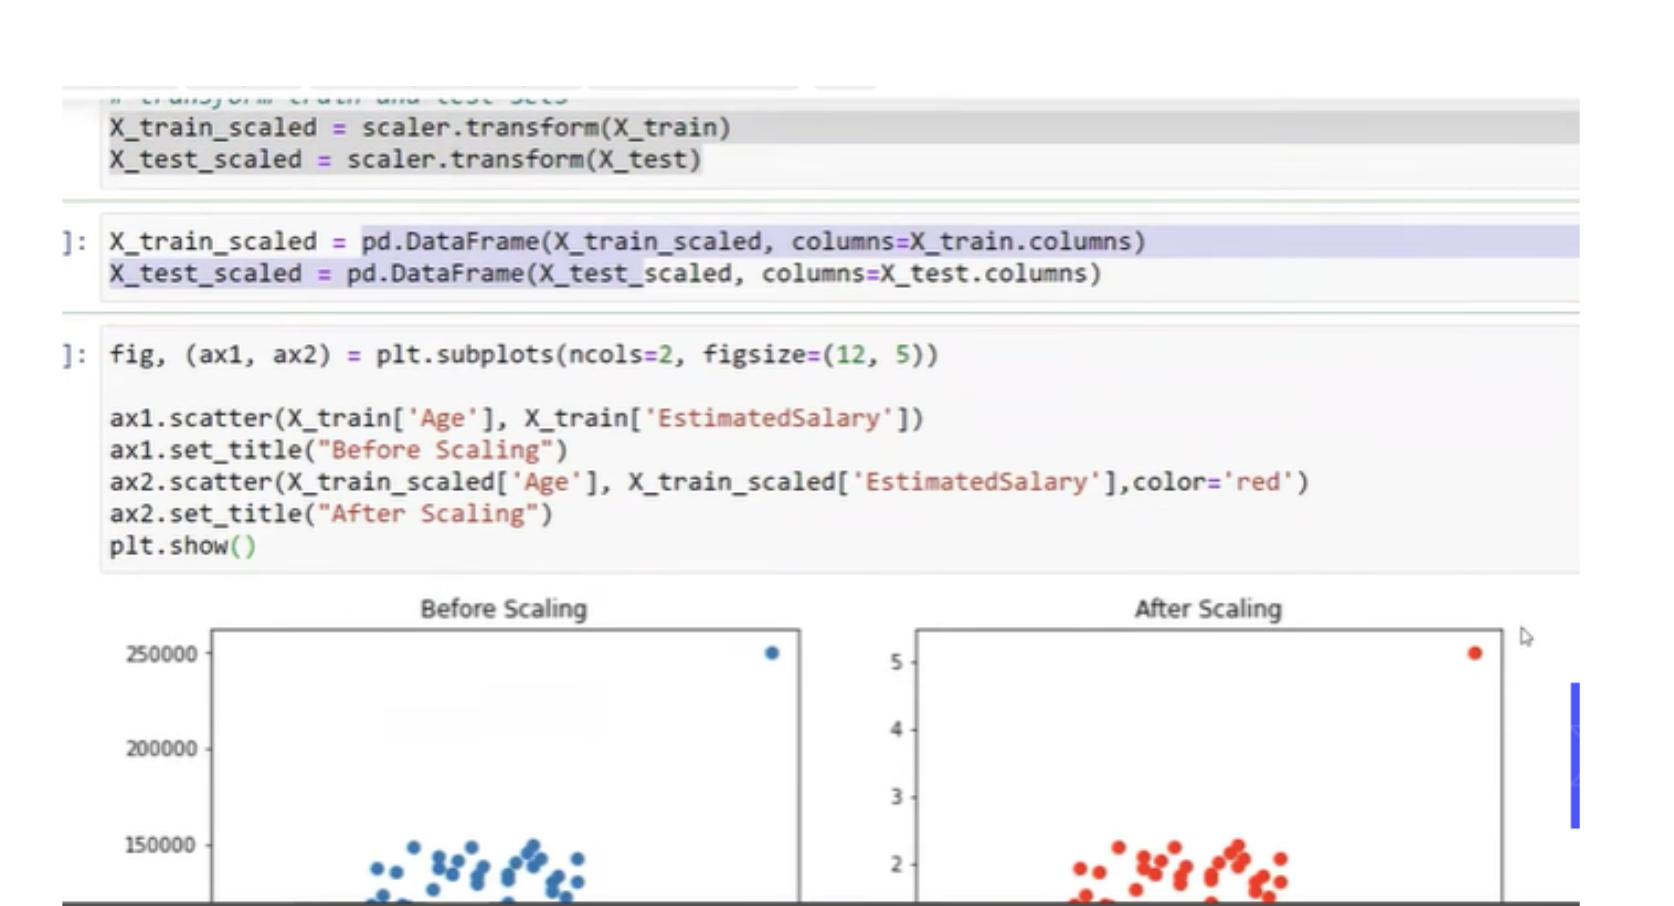

If you apply std on outliers data then outliers impacts not reduce, they behave same. THen you need to handle them explicitly
>
>
In first two algorithms you need to use ucaranian distance . when you need to find distance e.g railwas etc then we use this.
>
>
In PCA you need to controll variance and mean centring

# Normalization

99% of time, we use minmaxing normalization


One thing we need to remember is to know min value & max value. New distrution range must be in 0,1 range

In [75]:
df = pd.read_csv("../datasets/WineQT.csv", header=None,usecols=[0,1,2])
df.columns = ["Class label", "Alcohol", "Malic acid"] # alcohol and malic acid are input and class label is output

In [76]:
df

,Class label,Alcohol,Malic acid
0,fixed acidity,volatile acidity,citric acid
1,7.4,0.7,0.0
2,7.8,0.88,0.0
3,7.8,0.76,0.04
4,11.2,0.28,0.56
...,...,...,...
1139,6.3,0.51,0.13
1140,6.8,0.62,0.08
1141,6.2,0.6,0.08
1142,5.9,0.55,0.1


In [77]:
df["Alcohol"].dtype


dtype('O')

In [80]:
df["Alcohol"] = pd.to_numeric(df["Alcohol"], errors="coerce")
df = df.dropna(subset=["Alcohol"])


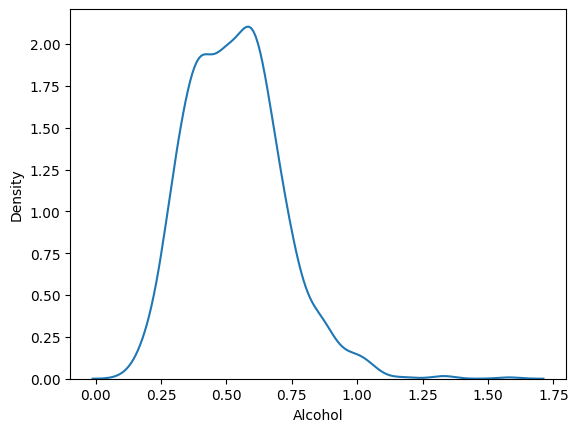

In [81]:
sns.kdeplot(x=df["Alcohol"])
plt.show()

In [82]:
df["Malic acid"] = pd.to_numeric(df["Malic acid"], errors="coerce")
df = df.dropna(subset=["Malic acid"])

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_28669/3903018951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Malic acid"] = pd.to_numeric(df["Malic acid"], errors="coerce")


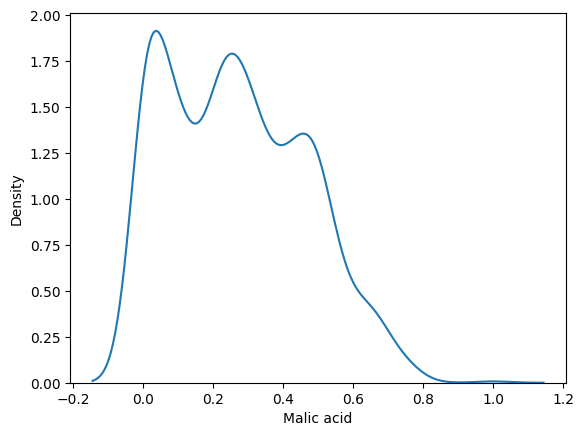

In [83]:
sns.kdeplot(x=df["Malic acid"])
plt.show()

In [84]:
df["Class label"].unique()


array(['7.4', '7.8', '11.2', '7.9', '7.3', '6.7', '5.6', '8.5', '7.6',
       '6.9', '6.3', '7.1', '8.3', '5.2', '8.1', '8.8', '7.5', '4.6',
       '7.7', '6.6', '8.6', '10.2', '7.0', '7.2', '8.0', '6.8', '6.2',
       '9.3', '5.0', '8.4', '10.1', '9.4', '8.2', '5.8', '9.2', '8.9',
       '6.4', '11.5', '9.6', '12.8', '9.7', '8.7', '12.0', '15.0', '10.8',
       '11.1', '10.0', '12.5', '10.3', '11.4', '9.9', '11.6', '10.4',
       '13.3', '10.6', '9.0', '9.8', '13.4', '11.9', '10.9', '13.8',
       '9.1', '13.5', '6.1', '10.5', '12.6', '13.7', '9.5', '12.2',
       '12.3', '15.6', '5.3', '11.3', '13.0', '6.5', '10.7', '12.9',
       '14.3', '12.4', '15.5', '12.7', '13.2', '15.9', '5.1', '11.8',
       '4.9', '5.9', '11.7', '5.4', '5.7', '6.0'], dtype=object)

In [85]:
df["Class label"].dtype


dtype('O')

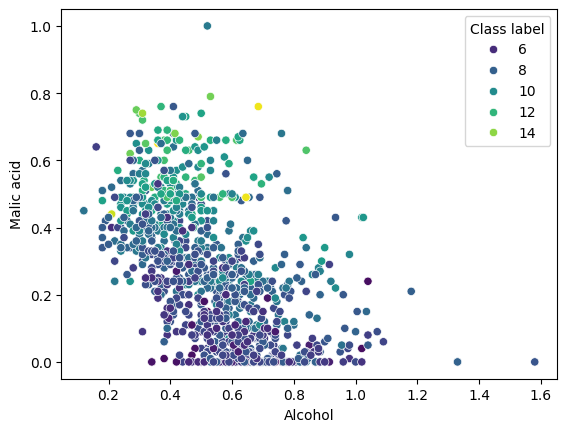

In [86]:
df["Class label"] = pd.to_numeric(df["Class label"], errors="coerce")

sns.scatterplot(
    x="Alcohol",
    y="Malic acid",
    hue="Class label",
    palette="viridis",   # numeric palette
    data=df
)

plt.show()


In [87]:
df["Class"] = pd.cut(
    df["Class label"].astype(float),
    bins=3,
    labels=[1,2,3]
)

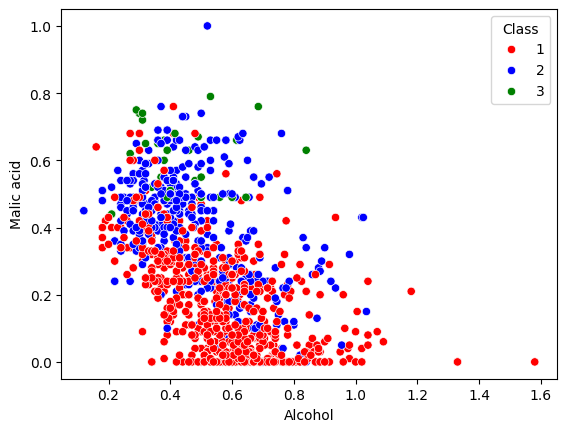

In [93]:
sns.scatterplot(
    x="Alcohol",
    y="Malic acid",
    hue="Class",
    palette={1:"red", 2:"blue", 3:"green"},
    data=df,
)
plt.show()

In [94]:
df

,Class label,Alcohol,Malic acid,Class
1,7.4,0.700,0.00,1
2,7.8,0.880,0.00,1
3,7.8,0.760,0.04,1
4,11.2,0.280,0.56,2
5,7.4,0.700,0.00,1
...,...,...,...,...
1139,6.3,0.510,0.13,1
1140,6.8,0.620,0.08,1
1141,6.2,0.600,0.08,1
1142,5.9,0.550,0.10,1


In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Class label", axis=1),
                                                    df["Class label"],
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((800, 3), (343, 3))

In [96]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scalar to the train set, it will learn the parameters
scaler.fit(X_train)

# transform both train and test set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [98]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,800.0,800.0
mean,0.5,0.3
std,0.2,0.2
min,0.1,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.6,0.4
max,1.3,0.8


In [99]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid,Class
count,800.0,800.0,800.0
mean,0.3,0.3,0.2
std,0.1,0.2,0.3
min,0.0,0.0,0.0
25%,0.2,0.1,0.0
50%,0.3,0.3,0.0
75%,0.4,0.5,0.5
max,1.0,1.0,1.0


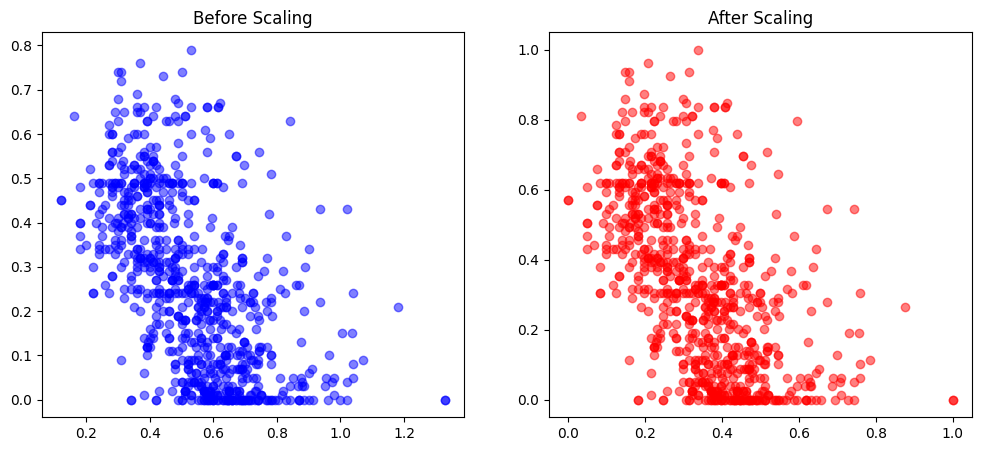

In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_train["Alcohol"], X_train["Malic acid"], c='blue', alpha=0.5)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic acid"], c='red', alpha=0.5)
ax2.set_title("After Scaling")
plt.show()

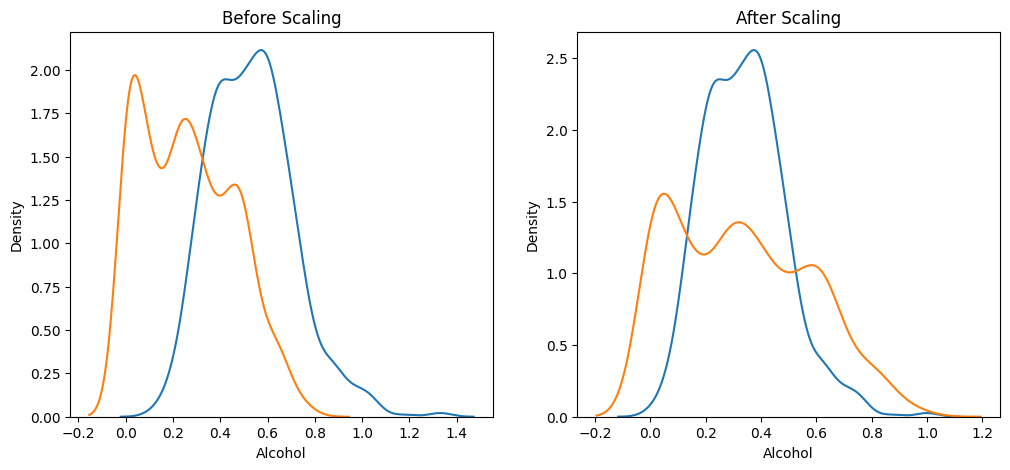

In [101]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)
sns.kdeplot(X_train["Malic acid"], ax=ax1)


ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"], ax=ax2)
sns.kdeplot(X_train_scaled["Malic acid"], ax=ax2)
plt.show()

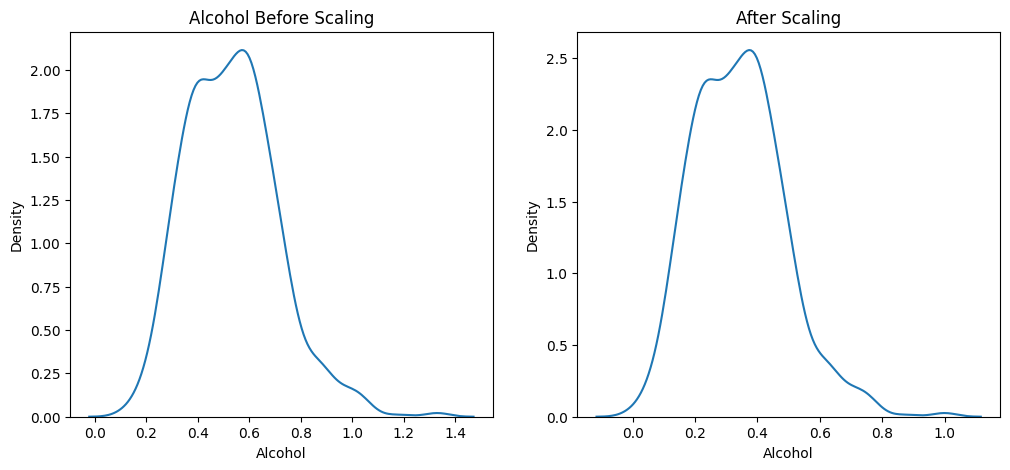

In [102]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Alcohol Before Scaling")
sns.kdeplot(X_train["Alcohol"],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Alcohol"], ax=ax2)
plt.show()

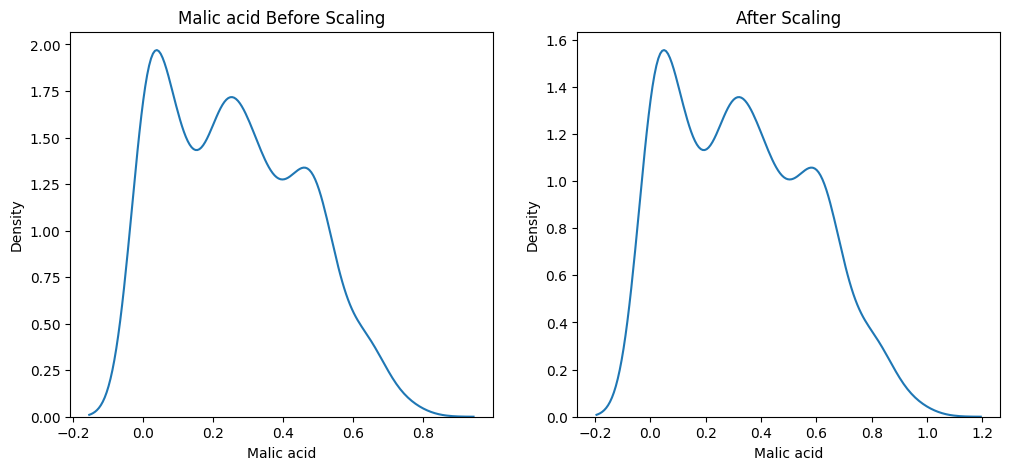

In [103]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Malic acid Before Scaling")
sns.kdeplot(X_train["Malic acid"],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Malic acid"], ax=ax2)
plt.show()

if there are a lot of outliers in data its perform better

- if you know already that your nnumerical quantity must stay in specific box then use minmax scaling.

- When you dont know anything then use std.

- When there are outliers then use roboust scaling.

- When you know data is sparse matric then use maxabs scaling.